# 07 — Fine-tuning do BERTimbau

Este notebook ajusta o checkpoint `neuralmind/bert-base-portuguese-cased` para a classificação binária de oportunidade comercial no nível do chunk. O treino usa exatamente as mesmas reuniões e os mesmos pseudo-rótulos do baseline TF-IDF + Regressão Logística.

> **Limite metodológico:** a validação atual usa pseudo-rótulos. As métricas permitem comparar os dois algoritmos sob a mesma referência, mas não medem ainda a qualidade real contra decisões humanas.

**Objetivo e conexão com o projeto.** Esta etapa ajusta o BERTimbau para o mesmo alvo, dados e partições usados pelo baseline, tornando a comparação posterior tecnicamente coerente. O treinamento preserva o limite de 512 tokens, aplica pesos de classe e seleciona o checkpoint pela validação. As métricas continuam sendo uma pseudo-validação, não evidência de desempenho em produção.


## 1. Decisões de treinamento

- Checkpoint: `neuralmind/bert-base-portuguese-cased`.
- Comprimento máximo: 512 tokens, preservando os 510 tokens de conteúdo definidos no chunking mais os tokens especiais do BERT.
- Batch físico 4 e acumulação de 2 passos produzem batch efetivo 8.
- Precisão mista FP16 é ativada apenas quando CUDA está disponível.
- Pesos de classe compensam o desbalanceamento dos pseudo-rótulos de treino.
- AdamW, learning rate `2e-5`, weight decay `0.01`, warmup linear de 10% e no máximo 3 épocas.
- O melhor checkpoint é escolhido pelo F1 da classe oportunidade; o recall dessa classe permanece a métrica principal de negócio.
- O split por reunião é validado novamente antes do treino.
- Textos das transcrições não aparecem nas saídas do notebook nem nos relatórios versionáveis.

As escolhas abaixo delimitam o experimento e devem ser lidas antes da implementação. Elas registram o que o código efetivamente faz e quais limitações precisam permanecer visíveis na interpretação.


## 2. Preparação do ambiente

Nesta célula são reunidos imports, parâmetros e caminhos necessários à etapa. Centralizar essa preparação antes do processamento deixa as dependências explícitas e evita que configurações importantes fiquem dispersas entre transformações, treinamento ou avaliação.


In [ ]:
from __future__ import annotations

import json
import math
import os
import platform
import random
import tempfile
import time
import warnings
from collections import Counter
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "wedjat-matplotlib"))
warnings.filterwarnings("ignore", message="IProgress not found.*")

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import transformers
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)


### Preparação do ambiente e das dependências

As bibliotecas são reunidas antes do processamento e organizam os recursos de dados, modelagem, avaliação e persistência usados nesta etapa. Parâmetros e caminhos permanecem explícitos para facilitar a reprodução local e no Colab.


In [ ]:
from torch.nn.utils import clip_grad_norm_
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)

SEED = 42
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"
MAX_LENGTH = 512
EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
PHYSICAL_BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 2
EFFECTIVE_BATCH_SIZE = PHYSICAL_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS
THRESHOLD = 0.5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


### Função auxiliar: `find_project_root`

Esta célula isola a responsabilidade implementada por `find_project_root`. A definição prepara essa operação para uso nas células seguintes e não altera os dados até ser chamada.


In [ ]:
def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Raiz do projeto não encontrada. No Colab, entre na pasta Wedjat.")


### Preparação dos objetos desta etapa

A célula prepara `ROOT`, `DATA_PATH`, `CHECKPOINT_DIR`, `PREDICTIONS_PATH` para a operação seguinte. O agrupamento mantém juntas apenas atribuições relacionadas e deixa a execução principal em uma célula própria.


In [1]:
ROOT = find_project_root()
DATA_PATH = ROOT / "data/processed/pseudo_labels_opportunity.jsonl"
CHECKPOINT_DIR = ROOT / "data/processed/bertimbau_opportunity_best"
PREDICTIONS_PATH = ROOT / "data/processed/bertimbau_validation_predictions.jsonl"
ERRORS_PATH = ROOT / "data/processed/bertimbau_validation_errors.jsonl"
METRICS_PATH = ROOT / "reports/metrics/bertimbau_finetuning_metrics.json"
FIGURE_PATH = ROOT / "reports/figures/bertimbau_confusion_matrix.png"

device_name = torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "CPU"
print({
    "device": str(DEVICE),
    "device_name": device_name,
    "torch": torch.__version__,
    "transformers": transformers.__version__,
    "effective_batch_size": EFFECTIVE_BATCH_SIZE,
})


{'device': 'cuda', 'device_name': 'NVIDIA GeForce RTX 3050', 'torch': '2.14.0+cu130', 'transformers': '5.17.0', 'effective_batch_size': 8}


## 3. Dados e proteção contra vazamento

O notebook usa o arquivo produzido pelo notebook 05. Nenhum novo sorteio é feito: essa é a condição necessária para comparar BERTimbau e baseline no mesmo conjunto.

Antes de transformar ou modelar, conferimos os dados usados nesta etapa e as condições que garantem comparabilidade. As verificações protegem a sequência do notebook contra arquivos incompletos e partições incompatíveis.


In [ ]:
def read_jsonl(path: Path) -> list[dict]:
    with path.open(encoding="utf-8") as file:
        return [json.loads(line) for line in file if line.strip()]


### Verificações de integridade

As asserções tornam explícitas as condições que precisam permanecer verdadeiras para que os resultados sejam considerados consistentes.


In [2]:
rows = read_jsonl(DATA_PATH)
required_fields = {"meeting_id", "chunk_id", "text", "pseudo_label", "weak_split"}
assert rows and all(required_fields <= row.keys() for row in rows)
assert {row["pseudo_label"] for row in rows} == {0, 1}

train_rows = [row for row in rows if row["weak_split"] == "train"]
validation_rows = [row for row in rows if row["weak_split"] == "validation"]
train_meetings = {row["meeting_id"] for row in train_rows}
validation_meetings = {row["meeting_id"] for row in validation_rows}
meeting_overlap = train_meetings & validation_meetings
assert not meeting_overlap, f"Vazamento entre {len(meeting_overlap)} reuniões."

y_train = np.asarray([row["pseudo_label"] for row in train_rows], dtype=np.int64)
y_validation = np.asarray([row["pseudo_label"] for row in validation_rows], dtype=np.int64)

print({
    "train_chunks": len(train_rows),
    "validation_chunks": len(validation_rows),
    "train_meetings": len(train_meetings),
    "validation_meetings": len(validation_meetings),
    "train_labels": dict(Counter(y_train.tolist())),
    "validation_labels": dict(Counter(y_validation.tolist())),
    "meeting_overlap": len(meeting_overlap),
})


{'train_chunks': 539, 'validation_chunks': 140, 'train_meetings': 388, 'validation_meetings': 98, 'train_labels': {1: 218, 0: 321}, 'validation_labels': {0: 82, 1: 58}, 'meeting_overlap': 0}


## 4. Tokenização e DataLoaders

A tokenização usa o limite completo de 512 tokens e padding dinâmico por batch. O padding em múltiplos de 8 melhora o aproveitamento dos Tensor Cores quando CUDA está ativa.

A tokenização traduz o texto para a representação aceita pelo modelo. Conferir tokens especiais, limites e máscaras é necessário para que cada entrada respeite a arquitetura e para que o chunking não dependa de uma estimativa por caracteres.


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


### Dataset tokenizado para o BERTimbau

A classe encapsula a tokenização dos textos e seus rótulos no formato esperado pelos DataLoaders, mantendo a preparação de entradas separada do laço de treinamento.


In [ ]:
class EncodedChunkDataset(Dataset):
    def __init__(self, source_rows: list[dict]):
        self.encodings = tokenizer(
            [row["text"] for row in source_rows],
            truncation=True,
            max_length=MAX_LENGTH,
            padding=False,
        )
        self.labels = [int(row["pseudo_label"]) for row in source_rows]

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, index: int) -> dict:
        item = {key: values[index] for key, values in self.encodings.items()}
        item["labels"] = self.labels[index]
        return item


### Preparação dos objetos desta etapa

A célula prepara `data_collator`, `loader_generator`, `train_loader`, `validation_loader` para a operação seguinte. O agrupamento mantém juntas apenas atribuições relacionadas e deixa a execução principal em uma célula própria.


In [ ]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer, pad_to_multiple_of=8 if DEVICE.type == "cuda" else None
)
loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    EncodedChunkDataset(train_rows),
    batch_size=PHYSICAL_BATCH_SIZE,
    shuffle=True,
    generator=loader_generator,
    collate_fn=data_collator,
    num_workers=0,
    pin_memory=DEVICE.type == "cuda",
)
validation_loader = DataLoader(
    EncodedChunkDataset(validation_rows),
    batch_size=PHYSICAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator,
    num_workers=0,
    pin_memory=DEVICE.type == "cuda",
)

raw_lengths = [len(tokenizer.tokenize(row["text"])) + 2 for row in rows]
effective_lengths = [min(length, MAX_LENGTH) for length in raw_lengths]


### Execução da etapa

A célula aplica os objetos e funções preparados anteriormente a uma responsabilidade específica do fluxo. As saídas permanecem disponíveis para validação e interpretação nas células seguintes.


In [3]:
print({
    "max_length": MAX_LENGTH,
    "median_effective_length": float(np.median(effective_lengths)),
    "max_raw_length": max(raw_lengths),
    "fraction_truncated": round(sum(length > MAX_LENGTH for length in raw_lengths) / len(raw_lengths), 4),
    "train_batches_per_epoch": len(train_loader),
})


{'max_length': 512, 'median_effective_length': 511.0, 'max_raw_length': 512, 'fraction_truncated': 0.0, 'train_batches_per_epoch': 135}


## 5. Modelo, pesos de classe e treinamento

A função de perda recebe pesos inversamente proporcionais à frequência de cada classe no treino. Gradient checkpointing e FP16 reduzem o uso de memória da GPU.

O ajuste usa somente a partição de treino e conserva a validação para seleção e comparação. Hiperparâmetros, balanceamento e critério de checkpoint são registrados para tornar o experimento reproduzível.


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "nao_oportunidade", 1: "oportunidade"},
    label2id={"nao_oportunidade": 0, "oportunidade": 1},
).to(DEVICE)
model.gradient_checkpointing_enable()
model.config.use_cache = False

class_counts = np.bincount(y_train, minlength=2)
class_weights = torch.tensor(
    len(y_train) / (2.0 * class_counts), dtype=torch.float32, device=DEVICE
)

no_decay = ("bias", "LayerNorm.weight")
optimizer_groups = [
    {
        "params": [parameter for name, parameter in model.named_parameters() if not any(term in name for term in no_decay)],
        "weight_decay": WEIGHT_DECAY,
    },
    {
        "params": [parameter for name, parameter in model.named_parameters() if any(term in name for term in no_decay)],
        "weight_decay": 0.0,
    },
]
optimizer = AdamW(optimizer_groups, lr=LEARNING_RATE)
updates_per_epoch = math.ceil(len(train_loader) / GRADIENT_ACCUMULATION_STEPS)
total_update_steps = updates_per_epoch * EPOCHS
warmup_steps = max(1, round(total_update_steps * 0.10))
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_update_steps)


### Preparação dos objetos desta etapa

A célula prepara `scaler` para a operação seguinte. O agrupamento mantém juntas apenas atribuições relacionadas e deixa a execução principal em uma célula própria.


In [4]:
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

print({
    "parameters": sum(parameter.numel() for parameter in model.parameters()),
    "class_weights": [round(value, 4) for value in class_weights.detach().cpu().tolist()],
    "updates_per_epoch": updates_per_epoch,
    "total_update_steps": total_update_steps,
    "warmup_steps": warmup_steps,
})


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 18098.10it/s]


[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from t

{'parameters': 108924674, 'class_weights': [0.8396, 1.2362], 'updates_per_epoch': 68, 'total_update_steps': 204, 'warmup_steps': 20}


### Função de avaliação

A função concentra o cálculo de perdas, probabilidades, classes e métricas. Isolá-la garante que as mesmas regras sejam usadas durante a seleção e na avaliação final do checkpoint.


In [ ]:
def evaluate(current_model, loader: DataLoader) -> dict:
    current_model.eval()
    losses, labels_all, probabilities_all = [], [], []
    with torch.inference_mode():
        for batch in loader:
            batch = batch.to(DEVICE)
            labels = batch.pop("labels")
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
                logits = current_model(**batch).logits
                loss = F.cross_entropy(logits, labels, weight=class_weights)
            probabilities = torch.softmax(logits.float(), dim=-1)[:, 1]
            losses.extend([float(loss.item())] * labels.shape[0])
            labels_all.extend(labels.cpu().tolist())
            probabilities_all.extend(probabilities.cpu().tolist())
    labels_array = np.asarray(labels_all, dtype=np.int64)
    probabilities_array = np.asarray(probabilities_all, dtype=np.float64)
    predictions_array = (probabilities_array >= THRESHOLD).astype(np.int64)
    return {
        "loss": float(np.mean(losses)),
        "labels": labels_array,
        "probabilities": probabilities_array,
        "predictions": predictions_array,
        "accuracy": float(accuracy_score(labels_array, predictions_array)),
        "precision_oportunidade": float(precision_score(labels_array, predictions_array, zero_division=0)),
        "recall_oportunidade": float(recall_score(labels_array, predictions_array, zero_division=0)),
        "f1_oportunidade": float(f1_score(labels_array, predictions_array, zero_division=0)),
        "f1_macro": float(f1_score(labels_array, predictions_array, average="macro", zero_division=0)),
    }


### Preparação dos objetos desta etapa

A célula prepara `history`, `best_f1`, `best_epoch`, `training_started` para a operação seguinte. O agrupamento mantém juntas apenas atribuições relacionadas e deixa a execução principal em uma célula própria.


In [ ]:
history = []
best_f1 = -1.0
best_epoch = 0
training_started = time.perf_counter()
if DEVICE.type == "cuda":
    torch.cuda.reset_peak_memory_stats()


### Laço de treinamento por épocas

O modelo é ajustado no conjunto de treino e avaliado ao final de cada época. O melhor estado é persistido segundo o critério de validação definido no experimento.


In [ ]:
for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad(set_to_none=True)
    epoch_loss = 0.0
    examples_seen = 0

    for step, batch in enumerate(train_loader, start=1):
        batch = batch.to(DEVICE)
        labels = batch.pop("labels")
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            logits = model(**batch).logits
            loss = F.cross_entropy(logits, labels, weight=class_weights)
            scaled_loss = loss / GRADIENT_ACCUMULATION_STEPS
        scaler.scale(scaled_loss).backward()
        epoch_loss += float(loss.item()) * labels.shape[0]
        examples_seen += labels.shape[0]

        should_update = step % GRADIENT_ACCUMULATION_STEPS == 0 or step == len(train_loader)
        if should_update:
            scaler.unscale_(optimizer)
            clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)

    validation_result = evaluate(model, validation_loader)
    epoch_result = {
        "epoch": epoch,
        "train_loss": epoch_loss / examples_seen,
        "validation_loss": validation_result["loss"],
        "accuracy": validation_result["accuracy"],
        "precision_oportunidade": validation_result["precision_oportunidade"],
        "recall_oportunidade": validation_result["recall_oportunidade"],
        "f1_oportunidade": validation_result["f1_oportunidade"],
        "f1_macro": validation_result["f1_macro"],
    }
    history.append(epoch_result)
    print({key: round(value, 4) if isinstance(value, float) else value for key, value in epoch_result.items()})

    if validation_result["f1_oportunidade"] > best_f1:
        best_f1 = validation_result["f1_oportunidade"]
        best_epoch = epoch
        CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
        model.save_pretrained(CHECKPOINT_DIR)
        tokenizer.save_pretrained(CHECKPOINT_DIR)


### Preparação dos objetos desta etapa

A célula prepara `training_seconds`, `peak_gpu_memory_mb` para a operação seguinte. O agrupamento mantém juntas apenas atribuições relacionadas e deixa a execução principal em uma célula própria.


In [5]:
training_seconds = time.perf_counter() - training_started
peak_gpu_memory_mb = (
    torch.cuda.max_memory_allocated() / 1024**2 if DEVICE.type == "cuda" else 0.0
)
print({
    "best_epoch": best_epoch,
    "training_seconds": round(training_seconds, 2),
    "peak_gpu_memory_mb": round(peak_gpu_memory_mb, 2),
})


{'epoch': 1, 'train_loss': 0.3447, 'validation_loss': 0.1253, 'accuracy': 0.9357, 'precision_oportunidade': 0.8657, 'recall_oportunidade': 1.0, 'f1_oportunidade': 0.928, 'f1_macro': 0.935}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.27s/it]

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.27s/it]

{'epoch': 2, 'train_loss': 0.1342, 'validation_loss': 0.0858, 'accuracy': 0.9714, 'precision_oportunidade': 0.9355, 'recall_oportunidade': 1.0, 'f1_oportunidade': 0.9667, 'f1_macro': 0.9708}


...

{'epoch': 3, 'train_loss': 0.0616, 'validation_loss': 0.042, 'accuracy': 0.9786, 'precision_oportunidade': 0.9661, 'recall_oportunidade': 0.9828, 'f1_oportunidade': 0.9744, 'f1_macro': 0.978}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.92s/it]

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.93s/it]

{'best_epoch': 3, 'training_seconds': 103.75, 'peak_gpu_memory_mb': 2137.55}


## 6. Avaliação do melhor checkpoint

Recarregamos o melhor checkpoint antes de calcular a matriz e o relatório completo. A matriz segue `[[TN, FP], [FN, TP]]`.

A avaliação transforma as previsões em medidas comparáveis e mantém a unidade de análise explícita. Como os rótulos atuais são automáticos, os números descrevem o experimento de desenvolvimento e não desempenho comprovado em produção.


In [ ]:
del model
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
best_model = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT_DIR).to(DEVICE)
final_result = evaluate(best_model, validation_loader)
final_labels = final_result.pop("labels")
final_probabilities = final_result.pop("probabilities")
final_predictions = final_result.pop("predictions")
matrix = confusion_matrix(final_labels, final_predictions, labels=[0, 1])
report = classification_report(
    final_labels,
    final_predictions,
    labels=[0, 1],
    target_names=["nao_oportunidade", "oportunidade"],
    output_dict=True,
    zero_division=0,
)
full_metrics = {
    "loss": final_result["loss"],
    "accuracy": final_result["accuracy"],
    "precision_oportunidade": final_result["precision_oportunidade"],
    "recall_oportunidade": final_result["recall_oportunidade"],
    "f1_oportunidade": final_result["f1_oportunidade"],
    "precision_macro": float(precision_score(final_labels, final_predictions, average="macro", zero_division=0)),
    "recall_macro": float(recall_score(final_labels, final_predictions, average="macro", zero_division=0)),
    "f1_macro": final_result["f1_macro"],
    "precision_weighted": float(precision_score(final_labels, final_predictions, average="weighted", zero_division=0)),
    "recall_weighted": float(recall_score(final_labels, final_predictions, average="weighted", zero_division=0)),
    "f1_weighted": float(f1_score(final_labels, final_predictions, average="weighted", zero_division=0)),
}


### Execução da etapa

A célula aplica os objetos e funções preparados anteriormente a uma responsabilidade específica do fluxo. As saídas permanecem disponíveis para validação e interpretação nas células seguintes.


In [6]:
tn, fp, fn, tp = (int(value) for value in matrix.ravel())

print({
    "best_epoch": best_epoch,
    "accuracy": round(full_metrics["accuracy"], 4),
    "precision_oportunidade": round(full_metrics["precision_oportunidade"], 4),
    "recall_oportunidade": round(full_metrics["recall_oportunidade"], 4),
    "f1_oportunidade": round(full_metrics["f1_oportunidade"], 4),
    "f1_macro": round(full_metrics["f1_macro"], 4),
    "confusion_matrix": matrix.tolist(),
})


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:  17%|█▋        | 35/201 [00:00<00:00, 349.61it/s]

Loading weights:  35%|███▍      | 70/201 [00:00<00:00, 305.49it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 862.93it/s]

{'best_epoch': 3, 'accuracy': 0.9786, 'precision_oportunidade': 0.9661, 'recall_oportunidade': 0.9828, 'f1_oportunidade': 0.9744, 'f1_macro': 0.978, 'confusion_matrix': [[80, 2], [1, 57]]}


### Visualização da matriz de confusão

A matriz apresenta acertos e erros por classe. Ela complementa as métricas agregadas ao mostrar diretamente quais tipos de erro ocorreram.


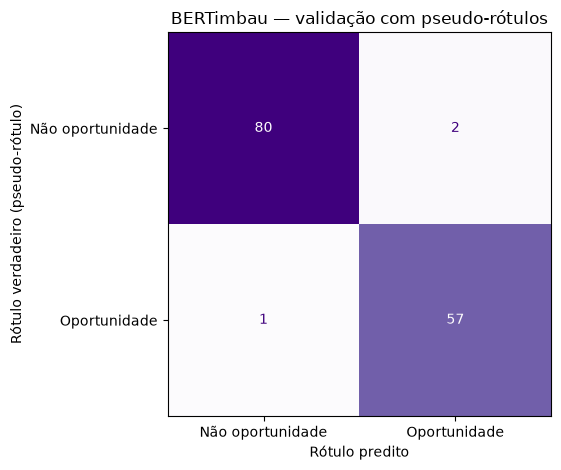

In [7]:
FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
display = ConfusionMatrixDisplay(
    confusion_matrix=matrix, display_labels=["Não oportunidade", "Oportunidade"]
)
display.plot(cmap="Purples", values_format="d", colorbar=False)
display.ax_.set_xlabel("Rótulo predito")
display.ax_.set_ylabel("Rótulo verdadeiro (pseudo-rótulo)")
plt.title("BERTimbau — validação com pseudo-rótulos")
plt.tight_layout()
plt.savefig(FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()

## 7. Artefatos e relatório

As previsões e os erros ficam na pasta processada sem copiar textos. O relatório versionável contém configuração, histórico, métricas e tempos agregados.

Os artefatos persistem o que será consumido pelas próximas etapas e separam resultados agregados de dados sensíveis. IDs, configurações e métricas permitem auditoria sem copiar o texto das reuniões.


In [ ]:
prediction_rows = []
for row, expected, predicted, probability in zip(
    validation_rows, final_labels, final_predictions, final_probabilities
):
    prediction_rows.append({
        "meeting_id": row["meeting_id"],
        "chunk_id": row["chunk_id"],
        "pseudo_label": int(expected),
        "prediction": int(predicted),
        "probability_oportunidade": round(float(probability), 8),
        "correct_against_pseudo_label": bool(expected == predicted),
    })
error_rows = [row for row in prediction_rows if not row["correct_against_pseudo_label"]]
for path, output_rows in [(PREDICTIONS_PATH, prediction_rows), (ERRORS_PATH, error_rows)]:
    with path.open("w", encoding="utf-8") as file:
        for row in output_rows:
            file.write(json.dumps(row, ensure_ascii=False) + "\n")


### Consolidação do relatório da etapa

Configurações, contagens, métricas e alertas são reunidos em um resumo auditável. O relatório registra resultados agregados sem acrescentar novas transformações aos dados.


In [ ]:
summary = {
    "schema_version": "1.0",
    "model": "BERTimbau fine-tuned for sequence classification",
    "checkpoint": MODEL_NAME,
    "target": "oportunidade_comercial_binaria_no_chunk",
    "evaluation_reference": "pseudo_labels_rule_and_bert_agreement",
    "warning": "Estas métricas não estimam desempenho real; falta avaliação contra rótulos humanos.",
    "seed": SEED,
    "threshold": THRESHOLD,
    "train_chunks": len(train_rows),
    "validation_chunks": len(validation_rows),
    "train_meetings": len(train_meetings),
    "validation_meetings": len(validation_meetings),
    "meeting_overlap": len(meeting_overlap),
    "train_label_counts": dict(Counter(str(value) for value in y_train.tolist())),
    "validation_label_counts": dict(Counter(str(value) for value in y_validation.tolist())),
    "training_config": {
        "max_length": MAX_LENGTH,
        "epochs_requested": EPOCHS,
        "best_epoch": best_epoch,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "physical_batch_size": PHYSICAL_BATCH_SIZE,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "effective_batch_size": EFFECTIVE_BATCH_SIZE,
        "warmup_steps": warmup_steps,
        "class_weights": class_weights.detach().cpu().tolist(),
        "fp16": USE_AMP,
        "gradient_checkpointing": True,
    },
    "history": history,
    "metrics": full_metrics,
    "classification_report": report,
    "confusion_matrix_order": [["TN", "FP"], ["FN", "TP"]],
    "confusion_matrix": matrix.tolist(),
    "error_counts": {"false_positive": fp, "false_negative": fn, "total": len(error_rows)},
    "primary_metric": {
        "name": "recall_oportunidade",
        "value": full_metrics["recall_oportunidade"],
        "justification": "Perder uma oportunidade relevante tende a ser mais custoso do que revisar um falso positivo.",
    },
    "hardware": {
        "device": str(DEVICE),
        "device_name": device_name,
        "peak_gpu_memory_mb": peak_gpu_memory_mb,
    },
    "training_seconds": training_seconds,
    "python_version": platform.python_version(),
    "torch_version": torch.__version__,
    "transformers_version": transformers.__version__,
}


### Persistência dos artefatos

Os resultados desta etapa são gravados nos caminhos definidos para consumo posterior. O conteúdo persistido segue o contrato já estabelecido pelo projeto.


In [8]:
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)
METRICS_PATH.write_text(json.dumps(summary, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")

print({
    "saved_checkpoint": str(CHECKPOINT_DIR.relative_to(ROOT)),
    "saved_metrics": str(METRICS_PATH.relative_to(ROOT)),
    "saved_figure": str(FIGURE_PATH.relative_to(ROOT)),
    "validation_predictions": len(prediction_rows),
    "errors_without_text": len(error_rows),
})


{'saved_checkpoint': 'data\\processed\\bertimbau_opportunity_best', 'saved_metrics': 'reports\\metrics\\bertimbau_finetuning_metrics.json', 'saved_figure': 'reports\\figures\\bertimbau_confusion_matrix.png', 'validation_predictions': 140, 'errors_without_text': 3}


## 8. Próximo passo

O notebook 08 deverá ler os relatórios do baseline e do BERTimbau, conferir que ambos usaram o mesmo split e construir a comparação lado a lado. A conclusão final deve destacar que a pseudo-validação favorece sinais usados na criação dos próprios rótulos; somente a auditoria humana permitirá afirmar precisão real.

Os itens a seguir separam o que já foi demonstrado do que ainda depende de dados humanos, calibração ou evolução técnica. Assim, o notebook termina sem transformar resultados experimentais em garantias de produção.
